##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


---

#### **Import Required Libraries:**
Start by importing all required libraries.

In [33]:
! pip install pafy youtube_dl moviepy==1.0.3 decorator==4.4.2 pydot yt-dlp

In [34]:
import os
import cv2
import math
import pafy
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from moviepy.editor import *
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

**Set Numpy, Python & Tensorflow seeds to get consistent results.**

In [35]:
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

## Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
### **Step 1: Download and Extract the Dataset**


### **Step 2: Visualize the Data with its Labels**
Let's pick some random videos from each class of the dataset and display it, this will give us a good overview of how the dataset look like.

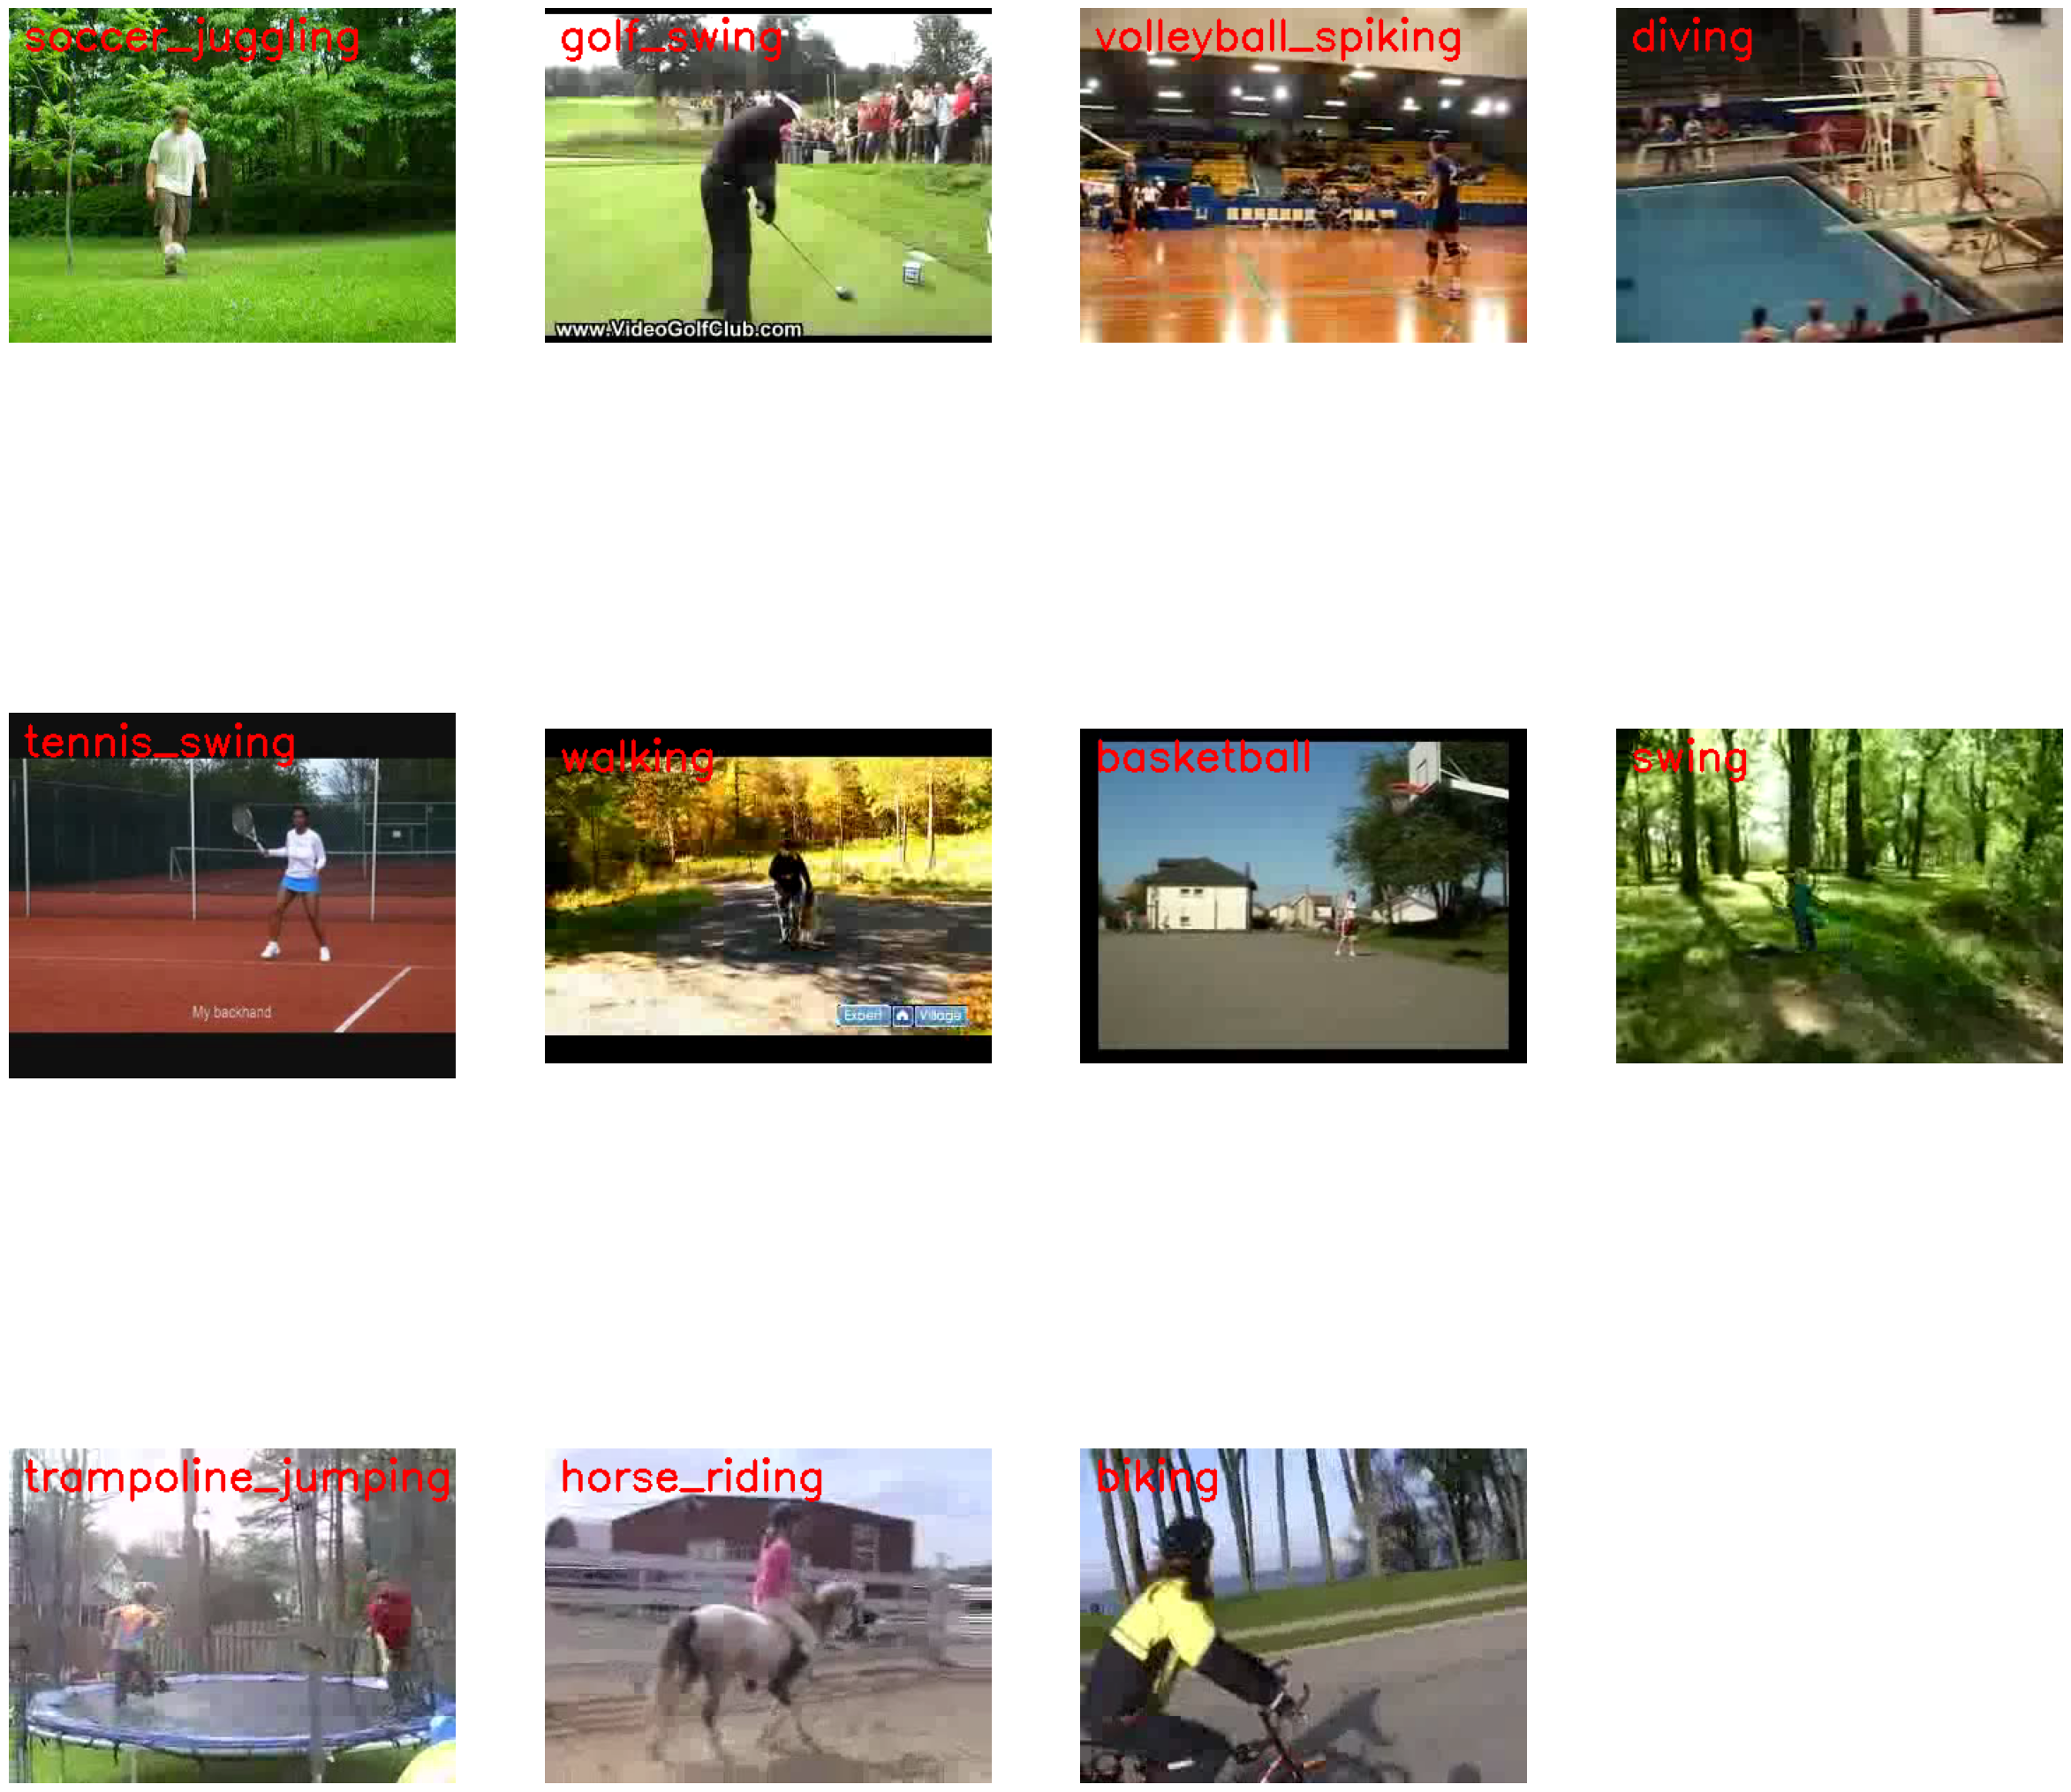

In [36]:
plt.figure(figsize = (30, 30))

# Correct base path
base_path = 'UCF11_updated_mpg/UCF11_updated_mpg'

# Get Names of all classes
all_classes_names = [c for c in os.listdir(base_path) if not c.startswith('.')]

random_range = random.sample(range(len(all_classes_names)), len(all_classes_names))

for counter, random_index in enumerate(random_range, 1):

    # Getting Class Name using Random Index
    selected_class_Name = all_classes_names[random_index]

    # Getting a list of all GROUP folders in a Class Directory, skip Annotation and hidden files
    group_folders_list = [g for g in os.listdir(f'{base_path}/{selected_class_Name}') 
                          if not g.startswith('.') and g != 'Annotation']

    # Randomly selecting a GROUP folder
    selected_group = random.choice(group_folders_list)

    # Get actual .mpg video files directly inside the group folder
    video_files_names_list = [v for v in os.listdir(f'{base_path}/{selected_class_Name}/{selected_group}') 
                               if v.endswith('.mpg')]

    # Skip if no valid videos found
    if not video_files_names_list:
        continue

    selected_video_file_name = random.choice(video_files_names_list)

    # Reading the Video File Using the Video Capture
    video_reader = cv2.VideoCapture(f'{base_path}/{selected_class_Name}/{selected_group}/{selected_video_file_name}')

    # Reading The First Frame of the Video File
    _, bgr_frame = video_reader.read()

    # Closing the VideoCapture object and releasing all resources. 
    video_reader.release()

    # Skip if frame is empty
    if bgr_frame is None:
        continue

    # Converting the BGR Frame to RGB Frame 
    rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)

    # Adding The Class Name Text on top of the Video Frame.
    cv2.putText(rgb_frame, selected_class_Name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    
    # Assigning the Frame to a specific position of a subplot
    plt.subplot(3, 4, counter)
    plt.imshow(rgb_frame)
    plt.axis('off')

## Preprocess the dataset.
### **Step 3: Read & Preprocess the Dataset**

Since we're going to use a classification architecture to train on a video classification dataset, we're going to need to preprocess the dataset first.

Now with the constants, 
- **`image_height`** and **`image_weight`**: This is the size we will resize all frames of the video to, we're doing this to avoid unneccsary computation.

- **`max_images_per_class`**: Maximum number of training images allowed for each class.

- **`dataset_directory`**: The path of the directory containing the extracted dataset. 

- **`classes_list`**: These are the list of classes we're going to be training on, we're traninng on following 3 classes, you can feel free to change it. 
  - *basketball*
  - *trampoline_jumping*
  - *walking*


In [42]:
image_height, image_width = 64, 64
max_images_per_class = 2500 

dataset_directory = "UCF11_updated_mpg/UCF11_updated_mpg"
classes_list = ["walking", "biking", "swing"]

model_output_size = len(classes_list)

### **Extract, Resize & Normalize Frames**


Now we'll create a function that will extract frames from each video while performing other preprocessing operation like resizing and normalizing images. 

This method takes a video file path as input. It then reads the video file frame by frame, resizes each frame, normalizes the resized frame, appends the normalized frame into a list and then finally returns that list.

In [43]:
def frames_extraction(video_path):
    # Empty List declared to store video frames
    frames_list = []
    
    # Reading the Video File Using the VideoCapture
    video_reader = cv2.VideoCapture(video_path)

    # Iterating through Video Frames
    while True:

        # Reading a frame from the video file 
        success, frame = video_reader.read() 

        # If Video frame was not successfully read then break the loop
        if not success:
            break

        # Resize the Frame to fixed Dimensions
        resized_frame = cv2.resize(frame, (image_height, image_width))
        
        # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1
        normalized_frame = resized_frame / 255
        
        # Appending the normalized frame into the frames list
        frames_list.append(normalized_frame)
    
    # Closing the VideoCapture object and releasing all resources. 
    video_reader.release()

    # returning the frames list 
    return frames_list

### **Dataset Creation**
Now we'll create another function called  **`create_dataset()`**,  this function uses the **`frame_extraction()`** funciton above and creates our final preprocessed dataset. 

**Here's how this function works:**

1.   Iterate through all the classes mentioned in the `classes_list`
2.   Now for each class iterate through all the video files present in it. 
3.   Call the **frame_extraction** method on each video file.
4.   Add the returned frames to a list called `temp_features`
5.   After all videos of a class are processed, randomly select video frames (equal to **max_images_per_class**) and add them to the list called `features`.
6.   Add labels of the selected videos to the labels list.
7.   After all videos of all classes are processed then return the features and labels as numpy arrays.


So when you call this function, it returns **2** lists:
- a list of feature vectors 
- a list of it's associated labels.


In [44]:
def create_dataset():

    # Declaring Empty Lists to store the features and labels values.
    temp_features = [] 
    features = []
    labels = []
    
    # Iterating through all the classes mentioned in the classes list
    for class_index, class_name in enumerate(classes_list):
        print(f'Extracting Data of Class: {class_name}')
        
        groups_list = os.listdir(os.path.join(dataset_directory, class_name))
        
        for group_name in groups_list:
            if group_name == 'Annotation':
                continue
                
            group_path = os.path.join(dataset_directory, class_name, group_name)            
            # Getting the list of video files present in the specific class name directory
            files_list = os.listdir(group_path)

            # Iterating through all the files present in the files list
            for file_name in files_list:

                # Construct the complete video path
                video_file_path = os.path.join(group_path, file_name)

                # Calling the frame_extraction method for every video file path
                frames = frames_extraction(video_file_path)

                # Appending the frames to a temporary list.
                temp_features.extend(frames)
        
        # Adding randomly selected frames to the features list
        sample_size = min(max_images_per_class, len(temp_features))
        features.extend(random.sample(temp_features, sample_size))

        # Adding Fixed number of labels to the labels list
        labels.extend([class_index] * sample_size)
        
        # Emptying the temp_features list so it can be reused to store all frames of the next class.
        temp_features.clear()

    # Converting the features and labels lists to numpy arrays
    features = np.asarray(features)
    labels = np.array(labels)  

    return features, labels

Calling the **create_dataset** method which returns features and labels.

In [45]:
features, labels = create_dataset()

Extracting Data of Class: walking
Extracting Data of Class: biking
Extracting Data of Class: swing


Now we will convert class labels to one hot encoded vectors.

In [46]:
# Using Keras's to_categorical method to convert labels into one-hot-encoded vectors
one_hot_encoded_labels = to_categorical(labels)

## Split the data into training and testing.
### **Step 4: Split the Data into Train and Test Set**
Now we have 2 numpy arrays, one containing all images, the second one contains all class labels in one hot encoded format. Let’s split our data to create a training and a testing set. It’s important that you shuffle your data before the split which we have already done.


In [47]:
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels, test_size = 0.2, shuffle = True, random_state = seed_constant)

## Create and train the model.

### **Step 5: Construct the Model**
Now it’s time to create our CNN model, for this post, we're c reating a simple CNN Classification model with two CNN layers.

In [48]:
# Let's create a function that will construct our model
def create_model():

    # We will use a Sequential model for model construction
    model = Sequential()

    # Defining The Model Architecture
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu', input_shape = (image_height, image_width, 3)))
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation = 'relu'))
    model.add(BatchNormalization())
    model.add(Dense(model_output_size, activation = 'softmax'))

    # Printing the models summary
    model.summary()

    return model


# Calling the create_model method
model = create_model()

print("Model Created Successfully!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

Model Created Successfully!


### **Check Model’s Structure:**
Using the **plot_model** function you can check the structure of the final model, this is really helpful when you’re creating a complex network and you want to make sure you have constructed the network correctly.

In [49]:
plot_model(model, to_file = 'model_structure_plot.png', show_shapes = True, show_layer_names = True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## **Step 6: Compile & Train the Model**


Now let's start the training. Before we do that, we also need to complile the model.


In [50]:
# Adding the Early Stopping Callback to the model which will continuously monitor the validation loss metric for every epoch.
# If the models validation loss does not decrease after 15 consecutive epochs, the training will be stopped and the weight which reported the lowest validation loss will be retored in the model.
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# Adding loss, optimizer and metrics values to the model.
model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start Training
model_training_history = model.fit(x = features_train, y = labels_train, epochs = 10, batch_size = 4 , shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback])

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.5171 - loss: 0.9879 - val_accuracy: 0.4525 - val_loss: 1.3078
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.5735 - loss: 0.9016 - val_accuracy: 0.3258 - val_loss: 2.3025
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.6227 - loss: 0.8315 - val_accuracy: 0.5758 - val_loss: 1.5578
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.6696 - loss: 0.7642 - val_accuracy: 0.6750 - val_loss: 0.9793
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.7060 - loss: 0.6963 - val_accuracy: 0.6125 - val_loss: 1.6983
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.7325 - loss: 0.6507 - val_accuracy: 0.6233 - val_loss: 1.2292
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.7588 - loss: 0.5986 - val_accuracy: 0.8058 - val_loss: 0.5995
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.7779 -

### **Evaluating Your Trained Model**
Evaluate your trained model on the feature's and label's test sets.

In [ ]:
model_evaluation_history = model.evaluate(features_test, labels_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8093 - loss: 0.6036


### **Save Your Model**
You should now save your model for future runs.

In [ ]:
# Creating a useful name for our model, incase you're saving multiple models (OPTIONAL)
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

student_name = "Layan" # Replace with your actual name
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")


Model saved as Layan_ucf11_model.h5


## **Step 7: Plot Model’s Loss & Accuracy Curves**
Let's plot our loss and accuracy curves.

In [ ]:
def plot_metric(metric_name_1, metric_name_2, plot_name):
  # Get Metric values using metric names as identifiers
  metric_value_1 = model_training_history.history[metric_name_1]
  metric_value_2 = model_training_history.history[metric_name_2]

  # Constructing a range object which will be used as time 
  epochs = range(len(metric_value_1))
  
  # Plotting the Graph
  plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
  plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)
  
  # Adding title to the plot
  plt.title(str(plot_name))

  # Adding legend to the plot
  plt.legend()

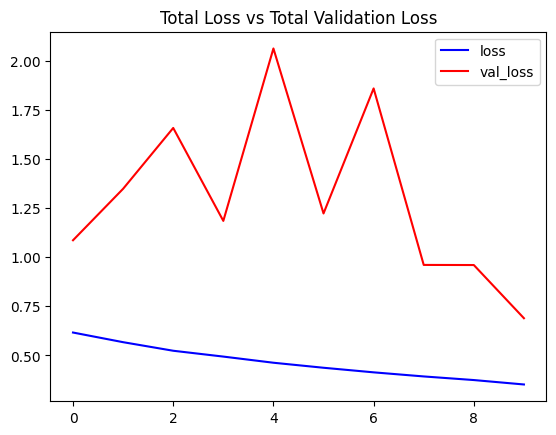

In [ ]:
plot_metric('loss', 'val_loss', 'Total Loss vs Total Validation Loss')

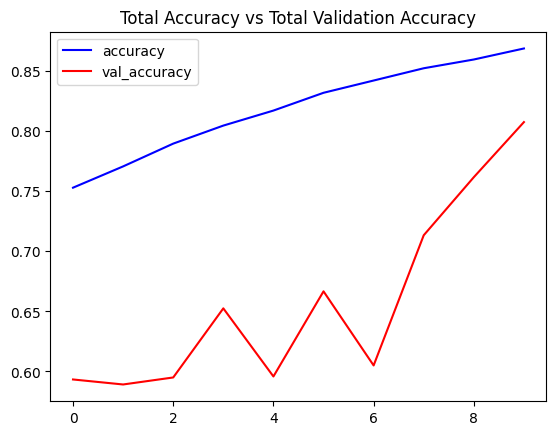

In [ ]:
plot_metric('accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

## Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes

### **Step 8: Make Predictions with the Model:**
Now that we have created and trained our model it's time to test it's performance on some test videos.


In [ ]:
def predict_on_live_video(video_file_path, output_file_path, window_size):

    # Initialize a Deque Object with a fixed size which will be used to implement moving/rolling average functionality.
    predicted_labels_probabilities_deque = deque(maxlen = window_size)

    # Reading the Video File using the VideoCapture Object
    video_reader = cv2.VideoCapture(video_file_path)

    # Getting the width and height of the video 
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Writing the Overlayed Video Files Using the VideoWriter Object
    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc('M', 'P', '4', 'V'), 24, (original_video_width, original_video_height))

    frame_num = 0
    prediction_counts = {}  # For summary at the end

    while True: 

        # Reading The Frame
        status, frame = video_reader.read() 

        if not status:
            break

        # Resize the Frame to fixed Dimensions
        resized_frame = cv2.resize(frame, (image_height, image_width))
        
        # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1
        normalized_frame = resized_frame / 255

        # Passing the Image Normalized Frame to the model and receiving Predicted Probabilities.
        predicted_labels_probabilities = model.predict(np.expand_dims(normalized_frame, axis = 0), verbose=0)[0]

        # Appending predicted label probabilities to the deque object
        predicted_labels_probabilities_deque.append(predicted_labels_probabilities)

        # Assuring that the Deque is completely filled before starting the averaging process
        if len(predicted_labels_probabilities_deque) == window_size:

            # Converting Predicted Labels Probabilities Deque into Numpy array
            predicted_labels_probabilities_np = np.array(predicted_labels_probabilities_deque)

            # Calculating Average of Predicted Labels Probabilities Column Wise 
            predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis = 0)

            # Converting the predicted probabilities into labels by returning the index of the maximum value.
            predicted_label = np.argmax(predicted_labels_probabilities_averaged)

            # Accessing The Class Name using predicted label.
            predicted_class_name = classes_list[predicted_label]

            # Print predicted class to notebook output every 10 frames
            if frame_num % 10 == 0:
                print(f"Frame {frame_num:>4}: Predicted Class → {predicted_class_name}")

            # Track predictions for final summary
            prediction_counts[predicted_class_name] = prediction_counts.get(predicted_class_name, 0) + 1
          
            # Overlaying Class Name Text Ontop of the Frame
            cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        # Writing The Frame
        video_writer.write(frame)

        # cv2.imshow('Predicted Frames', frame)

        # key_pressed = cv2.waitKey(10)

        # if key_pressed == ord('q'):
        #     break

        frame_num += 1

    # cv2.destroyAllWindows()

    # Print summary of all predicted classes
    print("\n--- Prediction Summary ---")
    for cls, count in sorted(prediction_counts.items(), key=lambda x: -x[1]):
        print(f"  {cls:<20} : {count} frames")
    print(f"  Most predicted class  : {max(prediction_counts, key=prediction_counts.get)}")

    # Closing the VideoCapture and VideoWriter objects and releasing all resources held by them. 
    video_reader.release()
    video_writer.release()

In [ ]:
os.makedirs('Youtube_Videos', exist_ok=True)

video_urls = {
    'walking': 'https://www.youtube.com/watch?v=Mol0lrRBy3g&pp=ygULd2Fsa2luZyB2aWQ%3D',
    'biking': 'https://youtu.be/cmw6hO2kHUU?si=cjhFk6p-oGmNGulR',
    'swing':   'https://www.youtube.com/watch?v=6iTymXuGFhg',
}

# Define local paths 
videos_to_test = {
    'walking': 'Youtube_Videos/walking.mp4',
    'biking':  'Youtube_Videos/biking.mp4',
    'swing':   'Youtube_Videos/swing.mp4',
}

#  Download videos
print("Downloading videos...")
for class_name, url in video_urls.items():
    output_path = videos_to_test[class_name]
    if os.path.exists(output_path):
        print(f"  Already exists: {output_path}")
        continue
    print(f"  Downloading {class_name} ...")
    !yt-dlp -f "best[ext=mp4]/best" -o "{output_path}" "{url}"
    print(f"  ✓ Saved → {output_path}")
print("All videos downloaded!\n")


[youtube] Extracting URL: https://www.youtube.com/watch?v=Mol0lrRBy3g&pp=ygULd2Fsa2luZyB2aWQ%3D
[youtube] Mol0lrRBy3g: Downloading webpage
[youtube] Mol0lrRBy3g: Downloading android vr player API JSON
[info] Mol0lrRBy3g: Downloading 1 format(s): 18
[download] Destination: Youtube_Videos/walking.mp4
[download] 100% of  933.09KiB in 00:00:00 at 1.31MiB/s0;33m00:00
  ✓ Saved → Youtube_Videos/walking.mp4
[youtube] Extracting URL: https://youtu.be/cmw6hO2kHUU?si=cjhFk6p-oGmNGulR
[youtube] cmw6hO2kHUU: Downloading webpage
[youtube] cmw6hO2kHUU: Downloading android vr player API JSON
[info] cmw6hO2kHUU: Downloading 1 format(s): 18
[download] Destination: Youtube_Videos/biking.mp4
[download] 100% of    7.69MiB in 00:00:02 at 2.67MiB/s0;33m00:000m
  ✓ Saved → Youtube_Videos/biking.mp4
[youtube] Extracting URL: https://www.youtube.com/watch?v=6iTymXuGFhg
[youtube] 6iTymXuGFhg: Downloading webpage
[youtube] 6iTymXuGFhg: Downloading android vr player API JSON
[info] 6iTymXuGFhg: Downloading 1 form

#### **Results Without Using Moving Average:**
First let's see the results when we're not using moving average, we can do this by setting the `window_size` to `1`.

In [ ]:
# Setting sthe Widow Size which will be used by the Rolling Averge Proces
window_size = 1

print("Results WITHOUT Moving Average (window_size = 1) : ")
print("=" * 55)

for class_name, input_path in videos_to_test.items():
    if not os.path.exists(input_path):
        print(f"  ⚠ File not found: {input_path}")
        continue
    output_path = f'Youtube_Videos/{class_name}_output_wsize1.avi'   
    predict_on_live_video(input_path, output_path, window_size=1)
    print(f"  ✓ {class_name:20s} → {output_path}")


Results WITHOUT Moving Average (window_size = 1) : 
  ✓ walking              → Youtube_Videos/walking_output_wsize1.avi
  ✓ biking               → Youtube_Videos/biking_output_wsize1.avi
  ✓ swing                → Youtube_Videos/swing_output_wsize1.avi


#### **Results When Using Moving Average:**
Now let's use moving average with a window size of `25`.

In [ ]:
print("Results WITH Moving Average (window_size = 25) : ")
print("=" * 55)

for class_name, input_path in videos_to_test.items():
    if not os.path.exists(input_path):
        print(f"  ⚠ File not found: {input_path}")
        continue
    output_path = f'Youtube_Videos/{class_name}_output_wsize25.avi'  
    predict_on_live_video(input_path, output_path, window_size=25)
    print(f"  ✓ {class_name:20s} → {output_path}")

print("\nAll predictions complete!")

Results WITH Moving Average (window_size = 25) : 
  ✓ walking              → Youtube_Videos/walking_output_wsize25.avi
  ✓ biking               → Youtube_Videos/biking_output_wsize25.avi
  ✓ swing                → Youtube_Videos/swing_output_wsize25.avi

All predictions complete!
